# Szenarios
This notebooks is supposed to save a scenario in the `data/` folder for quick access.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo

from src.data_preprocessing import SentinelClient
from src.helper_functions import calculate_rect_dimensions, collect_weather_data

/Users/hanno/PycharmProjects/Adv_Modelling_and_Simulation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters
Setting all the parameters (time, coordinates, ...) for the later data collection. This is the only cell that needs to be changed to save a different scenario.

In [2]:
name = "green_fire"

start_time = datetime.fromisoformat("2025-07-01T16:00")
start_date = ("2025-06-20", "2025-06-25")
end_date = ("2025-07-18", "2025-07-20")

lat_range = (40.720, 40.910)
lon_range = (-122.009, -122.179)

px_dimemnsion_km = 0.250

In [3]:
start_time = start_time.replace(tzinfo=ZoneInfo("America/Los_Angeles"))
start_time = start_time.astimezone(timezone.utc)
width_km, height_km = calculate_rect_dimensions(lat_range, lon_range)
width_px, height_px = round(width_km / px_dimemnsion_km), round(height_km / px_dimemnsion_km)
sc = SentinelClient()

## Data Collection
The true color photos are just to double check the choosen parameters.

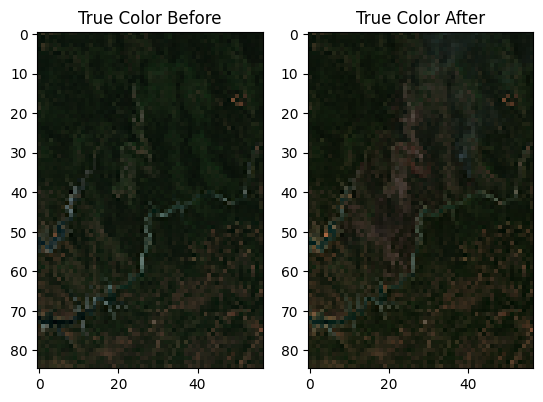

In [4]:
photo_true_colour_before, _ = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                           np.max(lon_range), np.max(lat_range),
                                           start_date[0], start_date[1], width_px, height_px)

photo_true_colour_after, end_time = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                          np.max(lon_range), np.max(lat_range),
                                          end_date[0], end_date[1], width_px, height_px)

plt.subplot(1, 2, 1)
plt.title("True Color Before")
plt.imshow(photo_true_colour_before);
plt.subplot(1, 2, 2)
plt.title("True Color After")
plt.imshow(photo_true_colour_after);

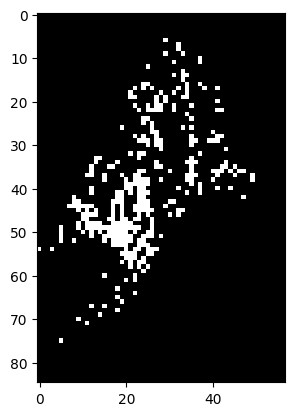

In [5]:
end_time = datetime.fromisoformat(end_time)
end_time = (end_time + timedelta(minutes=30)).replace(minute=0, second=0, microsecond=0)
delta_t = int((end_time - start_time).total_seconds() // 3600)

data_before = sc.get_data(np.min(lon_range), np.min(lat_range),
                          np.max(lon_range), np.max(lat_range),
                          start_date[0], start_date[1],
                          width_px, height_px)
fuel_before, water_before, moisture_before, burnt_before = data_before

data_after = sc.get_data(np.min(lon_range), np.min(lat_range),
                         np.max(lon_range), np.max(lat_range),
                         end_date[0], end_date[1],
                         width_px, height_px)
_, _, _, burnt_after_real_data = data_after
dnbr = (burnt_before - burnt_after_real_data)
_, burned_mask = sc.get_severity_mask(dnbr)
burned_mask = np.round(burned_mask).astype(int)

topo = sc.get_topo(np.min(lon_range), np.min(lat_range),
                   np.max(lon_range), np.max(lat_range),
                   width_px, height_px)

plt.imshow(burned_mask, cmap='gray');

In [9]:
weather_data = collect_weather_data(np.average(lat_range), np.average(lon_range),
                                    start_time, end_time)[:360]
wind_speed = weather_data["Wind Speed (kph)"].to_list()
wind_direction = weather_data["Wind Direction (°)"].to_list()
weather_data

,Time,Wind Speed (kph),Wind Direction (°)
23,2025-07-01 23:00:00+00:00,11.2,238
24,2025-07-02 00:00:00+00:00,13.9,266
25,2025-07-02 01:00:00+00:00,5.0,199
26,2025-07-02 02:00:00+00:00,4.4,102
27,2025-07-02 03:00:00+00:00,4.4,60
...,...,...,...
378,2025-07-16 18:00:00+00:00,8.1,239
379,2025-07-16 19:00:00+00:00,11.1,233
380,2025-07-16 20:00:00+00:00,13.0,227
381,2025-07-16 21:00:00+00:00,14.0,221


## Save Data

In [10]:
path = Path(f"../data/{name}")
path.mkdir(parents=True, exist_ok=True)
px = round(px_dimemnsion_km * 1000)

np.savetxt(path / f"burn_mask_px={px}m.csv", burned_mask, fmt='%d')
np.savetxt(path / f"fuel_mask_px={px}m.csv", fuel_before)
np.savetxt(path / f"moisture_mask_px={px}m.csv", moisture_before)
np.savetxt(path / f"topo_mask_px={px}m.csv", topo)
np.savetxt(path / f"water_mask_px={px}m.csv", water_before)
np.savetxt(path / f"wind_direction.csv", np.array(wind_direction))
np.savetxt(path / f"wind_speed.csv", np.array(wind_speed))
weather_data.to_csv(path / "weather_data.csv")